In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
# %matplotlib notebook
plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
import warnings

warnings.filterwarnings("ignore")
warnings.warn("this will not show")

In [2]:
df = pd.read_csv("livestock_growth_synthetic_dataset.csv")

In [3]:
df.head()

,animal_id,breed,sex,birth_weight_kg,withers_height_cm,chest_girth_cm,body_length_cm,colostrum_liters_first_week,early_health_score,ration_type,daily_dry_matter_intake_kg,disease_history_first_3m,weight_3m_kg,weight_6m_kg,weight_12m_kg
0,ANM-00001,Hereford,Female,31.1,74.4,77.1,61.6,24.8,5,high_energy,5.22,0,105.3,205.1,344.3
1,ANM-00002,Jersey,Male,40.8,70.3,78.6,59.7,8.6,4,standard,4.67,0,88.0,177.4,282.6
2,ANM-00003,Limuzin,Female,41.3,77.7,87.9,76.0,25.0,3,high_protein,5.52,1,109.9,188.2,296.6
3,ANM-00004,Angus,Female,33.1,75.8,92.0,85.7,25.0,5,standard,5.44,0,117.4,213.3,336.9
4,ANM-00005,Holstein,Male,39.1,79.1,87.0,73.8,22.2,4,high_energy,6.67,0,129.4,259.2,465.5


# 📊 Feature Descriptions

Bu veri seti, erken dönem biyometrik ve besleme verilerine dayanarak sığırların 6. ve 12. ay canlı ağırlıklarını tahmin etmek amacıyla oluşturulmuştur. Veri, biyolojik olarak makul ilişkiler gözetilerek sentetik olarak üretilmiştir.

---

## 🧬 Animal & Genetic Features

### **breed**

Hayvanın ırkını belirtir.
Farklı ırklar farklı büyüme potansiyeline sahiptir (örneğin etçi ırklar genellikle daha yüksek canlı ağırlığa ulaşır).

### **sex**

Hayvanın cinsiyeti (Male / Female).
Erkek hayvanlar genellikle daha yüksek büyüme performansı gösterir.

---

## 🐣 Early Life Features

### **birth_weight_kg**

Doğum ağırlığı (kg).
Erken büyüme performansının önemli bir göstergesidir.

### **colostrum_liters_first_week**

İlk hafta tüketilen kolostrum (ağız sütü) miktarı (litre).
Bağışıklık ve erken gelişim üzerinde kritik etkiye sahiptir.

### **early_health_score**

Erken dönem sağlık skoru (1–5 arası).
Düşük skorlar büyüme performansını olumsuz etkiler.

### **disease_history_first_3m**

İlk 3 ayda hastalık geçirip geçirmediği (0 = Hayır, 1 = Evet).
Hastalık geçmişi büyüme hızını düşürebilir.

---

## 📏 Morphological Features

### **withers_height_cm**

Cidago yüksekliği (cm).
İskelet gelişimini temsil eder ve büyüme potansiyelinin göstergesidir.

### **chest_girth_cm**

Göğüs çevresi (cm).
Vücut kapasitesi ve gelişim düzeyini yansıtır.

### **body_length_cm**

Vücut uzunluğu (cm).
Genel fiziksel gelişimi temsil eder.

---

## 🌾 Feeding Features

### **ration_type**

Uygulanan rasyon tipi:

* `standard`
* `high_energy`
* `high_protein`

Farklı rasyonlar büyüme hızını farklı şekilde etkiler.

### **daily_dry_matter_intake_kg**

Günlük kuru madde tüketimi (kg).
Büyümenin en önemli belirleyicilerinden biridir.

---

## 📈 Intermediate Feature

### **weight_3m_kg**

3 aylık canlı ağırlık (kg).
Ara dönem büyüme performansını temsil eder ve ileri dönem tahminleri için güçlü bir göstergedir.

---

## 🎯 Target Variables

### **weight_6m_kg**

6 aylık canlı ağırlık (kg).
Orta dönem büyüme çıktısı.

### **weight_12m_kg**

12 aylık canlı ağırlık (kg).
Final hedef değişken olup besi performansının ana göstergesidir.

---

## ⚠️ Not

Bu veri seti sentetik olarak oluşturulmuş olup:

* Biyolojik ilişkiler gözetilmiştir
* Rastgele değil, kurallı üretim yapılmıştır
* Gerçek dünya senaryolarını simüle etmeyi amaçlar

---


In [4]:
df.shape

(2000, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   animal_id                    2000 non-null   object 
 1   breed                        2000 non-null   object 
 2   sex                          2000 non-null   object 
 3   birth_weight_kg              2000 non-null   float64
 4   withers_height_cm            2000 non-null   float64
 5   chest_girth_cm               2000 non-null   float64
 6   body_length_cm               2000 non-null   float64
 7   colostrum_liters_first_week  2000 non-null   float64
 8   early_health_score           2000 non-null   int64  
 9   ration_type                  2000 non-null   object 
 10  daily_dry_matter_intake_kg   2000 non-null   float64
 11  disease_history_first_3m     2000 non-null   int64  
 12  weight_3m_kg                 2000 non-null   float64
 13  weight_6m_kg      

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
birth_weight_kg,2000.0,36.247700,4.362681,25.10,33.300,36.400,39.40,48.00
withers_height_cm,2000.0,74.893900,6.258180,60.00,70.700,75.200,79.40,92.00
chest_girth_cm,2000.0,83.587600,7.436492,68.00,78.000,83.800,88.80,102.00
body_length_cm,2000.0,72.917350,7.036336,58.10,68.000,72.800,77.80,91.70
colostrum_liters_first_week,2000.0,16.889900,4.920471,8.00,13.075,16.550,20.90,26.00
early_health_score,2000.0,3.652000,1.121394,1.00,3.000,4.000,5.00,5.00
daily_dry_matter_intake_kg,2000.0,4.541575,0.918276,1.87,3.900,4.515,5.15,7.36
disease_history_first_3m,2000.0,0.246500,0.431081,0.00,0.000,0.000,0.00,1.00
weight_3m_kg,2000.0,101.673550,20.355129,65.00,88.000,103.800,116.10,155.50
weight_6m_kg,2000.0,189.015100,34.079446,120.00,164.300,190.650,213.30,288.80


In [7]:
# TR: Veri seti incelendiğinde, değişkenlerin dağılımı genel olarak biyolojik açıdan makul aralıklarda görünmektedir. Aykırı değerler sınırlı düzeydedir ve veri seti modelleme için uygundur.
# EN: Initial inspection shows that feature distributions fall within biologically plausible ranges. Outliers are limited, and the dataset appears suitable for modeling.

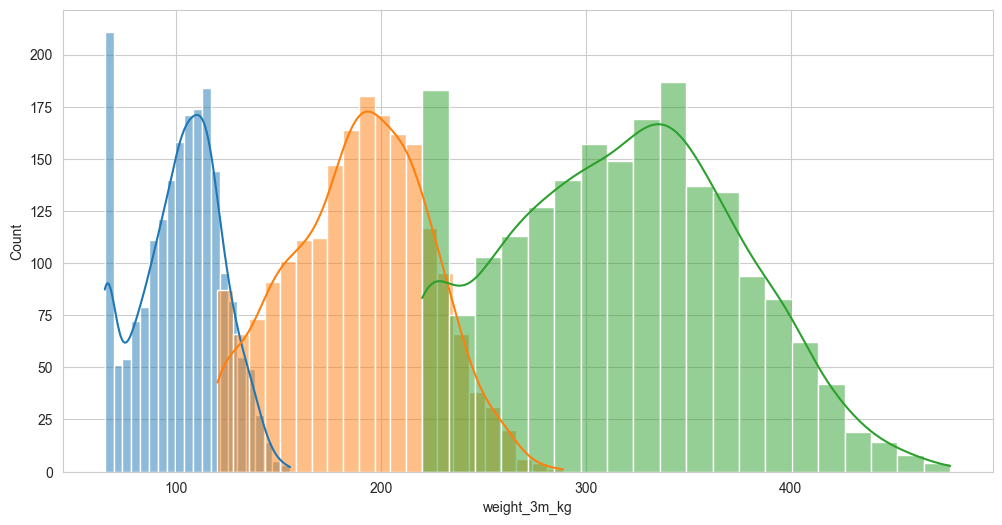

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["weight_3m_kg"], kde=True)
sns.histplot(df["weight_6m_kg"], kde=True)
sns.histplot(df["weight_12m_kg"], kde=True)
plt.show()

In [9]:
# TR: 3., 6. ve 12. ay ağırlık dağılımları incelendiğinde, genel olarak artan bir trend gözlemlenmektedir. Bu durum biyolojik büyüme süreci ile uyumludur.
# EN: The distributions of 3-month, 6-month, and 12-month weights show a consistent increasing trend, which aligns with expected biological growth patterns.

In [10]:
(df["weight_6m_kg"] > df["weight_3m_kg"]).mean()
(df["weight_12m_kg"] > df["weight_6m_kg"]).mean()

np.float64(1.0)

In [11]:
df[["birth_weight_kg","weight_3m_kg","weight_6m_kg","weight_12m_kg"]].corr()

,birth_weight_kg,weight_3m_kg,weight_6m_kg,weight_12m_kg
birth_weight_kg,1.000000,0.658165,0.522285,0.430023
weight_3m_kg,0.658165,1.000000,0.904469,0.811939
weight_6m_kg,0.522285,0.904469,1.000000,0.937253
weight_12m_kg,0.430023,0.811939,0.937253,1.000000


In [12]:
# TR: Doğum ağırlığı ile 3 aylık ağırlık arasında pozitif bir ilişki gözlemlenmektedir. Ayrıca 3 aylık ağırlık, 12 aylık ağırlığın güçlü bir belirleyicisi olarak öne çıkmaktadır.
# EN: Birth weight shows a positive correlation with 3-month weight, and 3-month weight appears to be a strong predictor of 12-month weight.

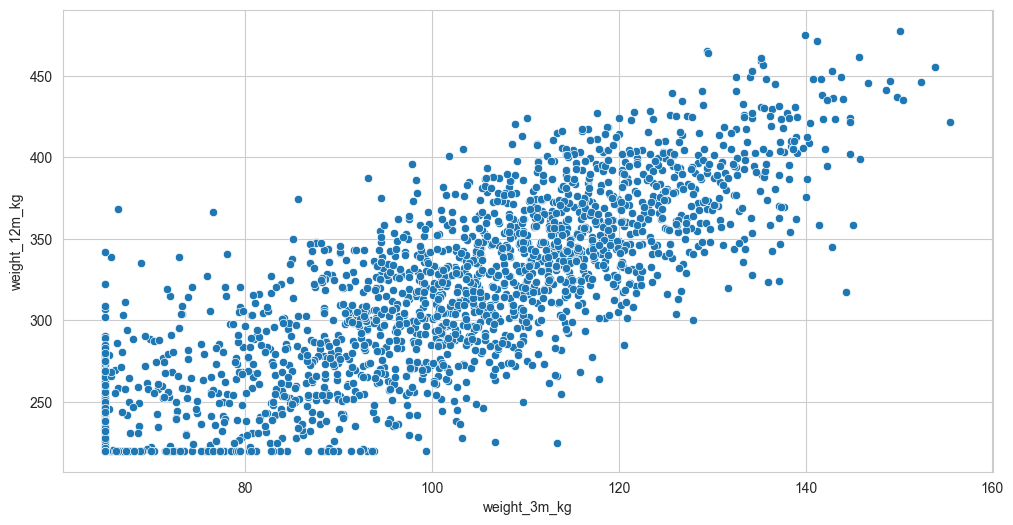

In [13]:
sns.scatterplot(x="weight_3m_kg", y="weight_12m_kg", data=df)
plt.show()

In [14]:
# Yukarı doğru trend.

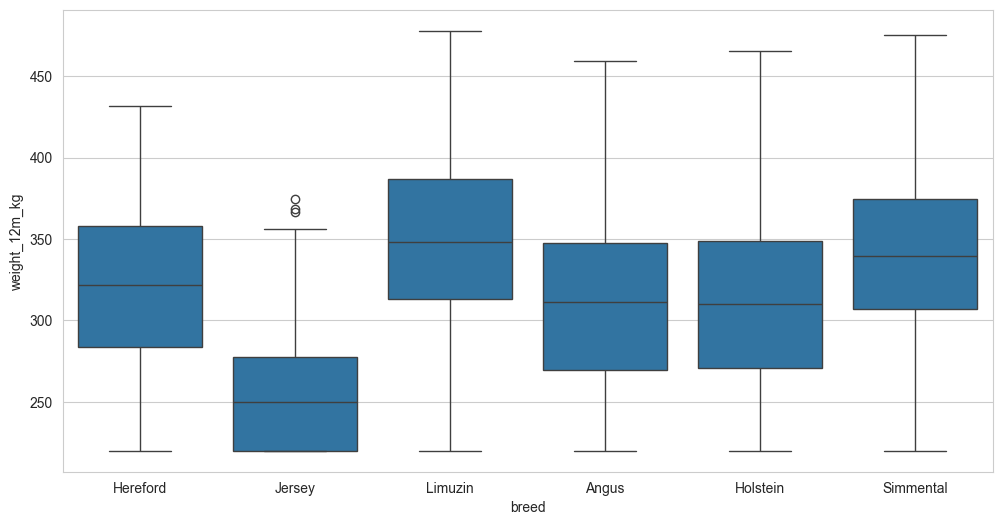

In [15]:
sns.boxplot(x="breed", y="weight_12m_kg", data=df)
plt.show()

In [16]:
# TR: Farklı ırklar arasında canlı ağırlık açısından belirgin farklar gözlemlenmektedir. Etçi ırklar genellikle daha yüksek ağırlık değerlerine ulaşmaktadır.
# EN: Clear differences are observed between breeds. Beef-type breeds tend to achieve higher weights compared to dairy-type breeds.

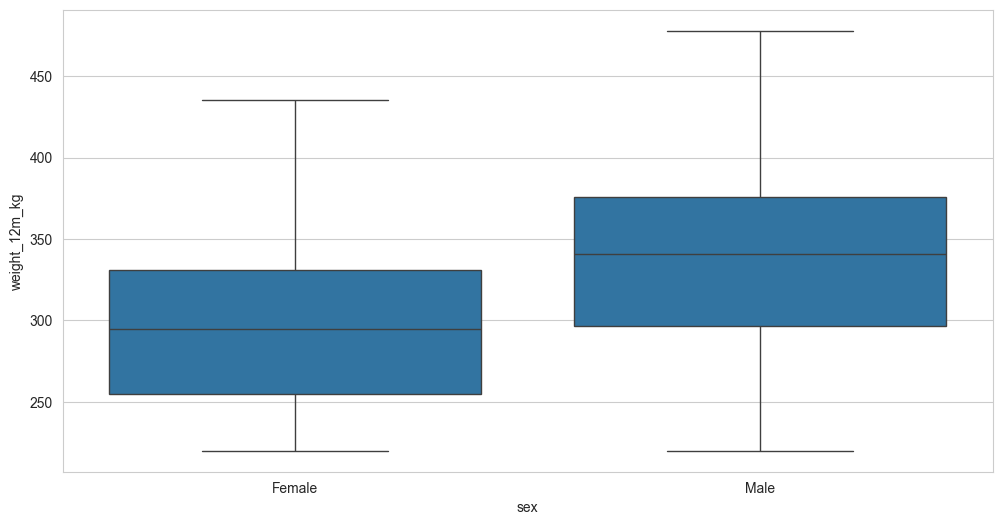

In [17]:
sns.boxplot(x="sex", y="weight_12m_kg", data=df)
plt.show()

In [18]:
# TR: Erkek hayvanların ortalama canlı ağırlıklarının dişilere göre daha yüksek olduğu gözlemlenmektedir.
# EN: Male animals generally show higher average weights compared to females.

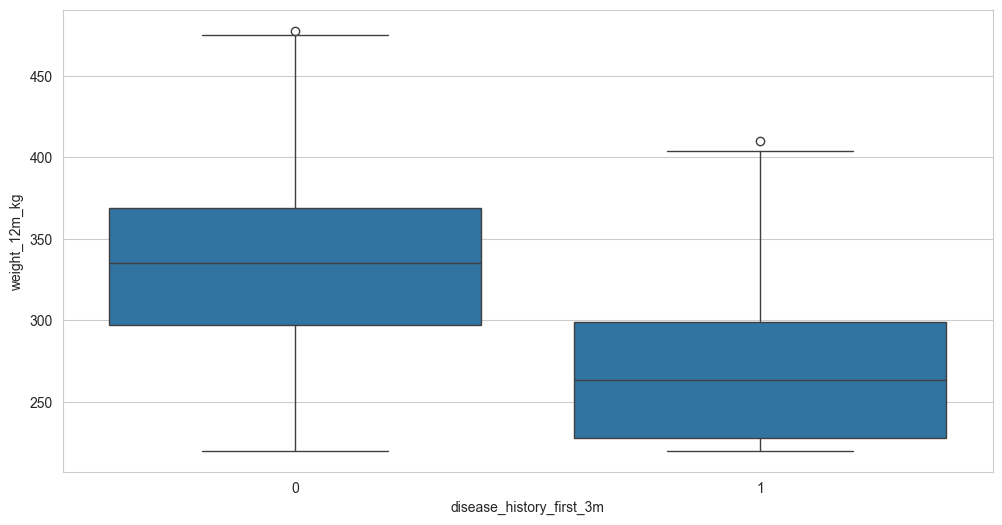

In [19]:
sns.boxplot(x="disease_history_first_3m", y="weight_12m_kg", data=df)
plt.show()

In [20]:
# TR: İlk 3 ayda hastalık geçiren hayvanların ileri dönem ağırlıklarının daha düşük olduğu gözlemlenmektedir.
# EN: Animals with disease history in the first 3 months tend to have lower weights in later periods.

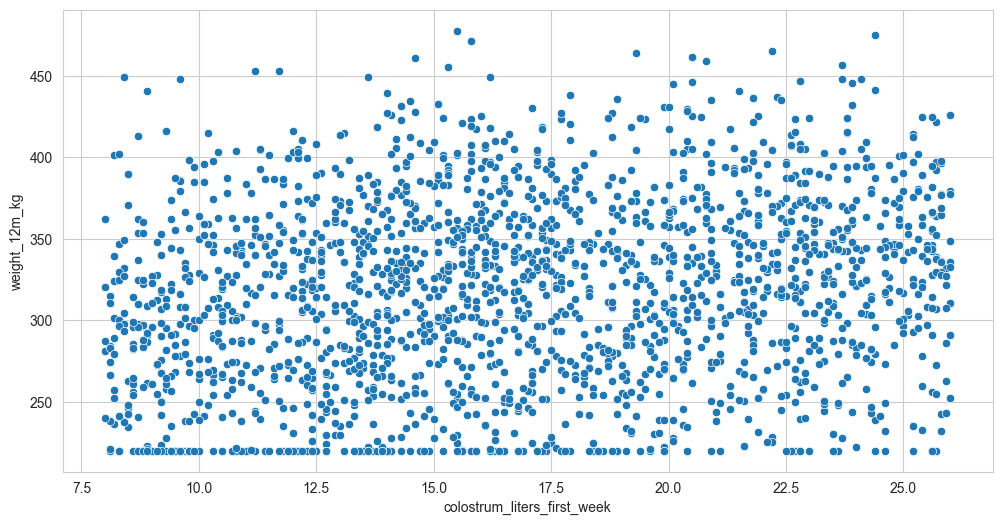

In [21]:
sns.scatterplot(x="colostrum_liters_first_week", y="weight_12m_kg", data=df)
plt.show()

In [22]:
# TR: Daha yüksek kolostrum tüketimi, daha iyi büyüme performansı ile ilişkilidir. Düşük kolostrum alan hayvanlarda gelişim geriliği gözlemlenebilir.
# EN: Higher colostrum intake is associated with improved growth performance, while low intake may negatively impact development.

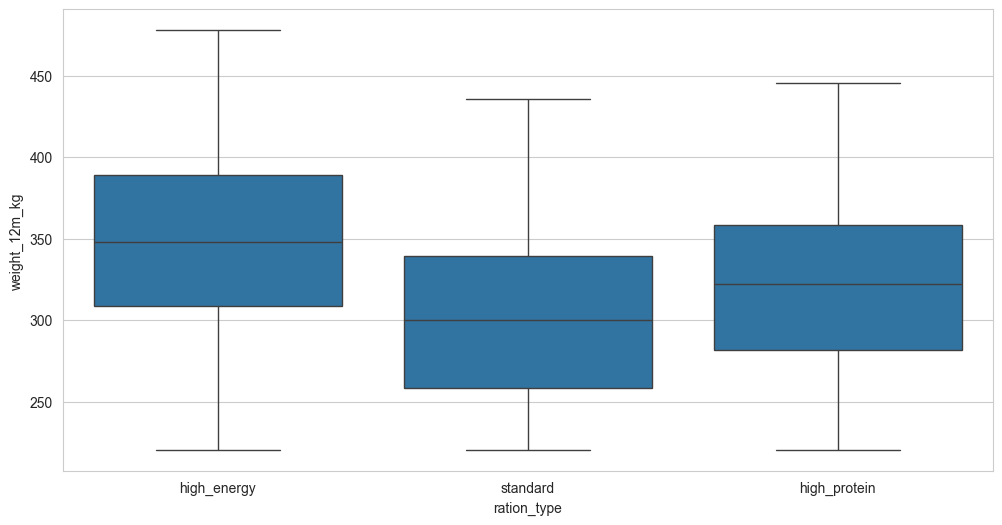

In [23]:
sns.boxplot(x="ration_type", y="weight_12m_kg", data=df)
plt.show()

In [24]:
# TR: Rasyon tipi ve kuru madde tüketimi, büyüme üzerinde önemli bir etkiye sahiptir. Enerji yoğun rasyonların daha yüksek ağırlık artışı sağladığı görülmektedir.
# EN: Ration type and dry matter intake significantly influence growth. High-energy diets tend to result in higher weight gain.

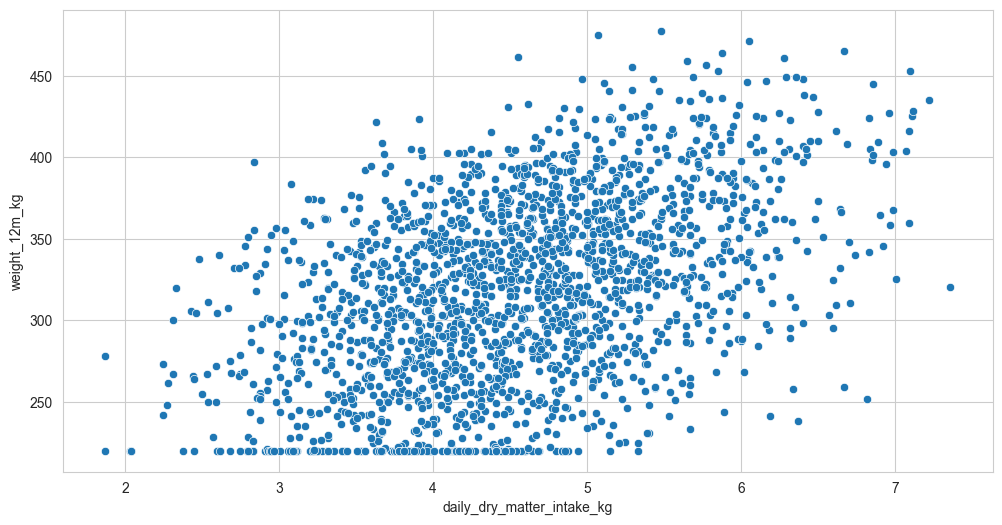

In [25]:
sns.scatterplot(x="daily_dry_matter_intake_kg", y="weight_12m_kg", data=df)
plt.show()

In [26]:
# TR: Veri setinde sınırlı sayıda aykırı değer bulunmaktadır. Bu değerler tamamen kaldırılmamış, gerçek veri dağılımını yansıtması amacıyla korunmuştur.
# EN: A limited number of outliers exist in the dataset. These were retained to preserve realistic variability.

In [27]:
# TR: Genel olarak veri seti, biyolojik olarak tutarlı ve modelleme için uygun bir yapı sergilemektedir. Özellikle erken dönem verilerinin ileri dönem ağırlık tahmini için güçlü bir gösterge olduğu görülmektedir.
# EN: Overall, the dataset demonstrates biological consistency and is suitable for modeling. Early-life features appear to be strong predictors of future weight.

In [28]:
df.select_dtypes(include="number").corr()["weight_12m_kg"].sort_values(ascending=False)

weight_12m_kg                  1.000000
weight_6m_kg                   0.937253
weight_3m_kg                   0.811939
daily_dry_matter_intake_kg     0.469398
birth_weight_kg                0.430023
withers_height_cm              0.423136
chest_girth_cm                 0.368969
body_length_cm                 0.318584
early_health_score             0.293043
colostrum_liters_first_week    0.188393
disease_history_first_3m      -0.481612
Name: weight_12m_kg, dtype: float64

## 🔗 Correlation Analysis

**TR:** Korelasyon analizi yalnızca sayısal değişkenler üzerinde gerçekleştirilmiştir. Sonuçlara göre, özellikle 3 aylık ağırlık (weight_3m_kg), 12 aylık ağırlığın en güçlü belirleyicilerinden biridir. Bu durum, erken dönem büyüme performansının ileri dönem sonuçlar üzerindeki etkisini göstermektedir.

**EN:** Correlation analysis was performed using only numerical features. The results indicate that weight at 3 months (weight_3m_kg) is one of the strongest predictors of 12-month weight. This highlights the importance of early growth performance in determining future outcomes.

---


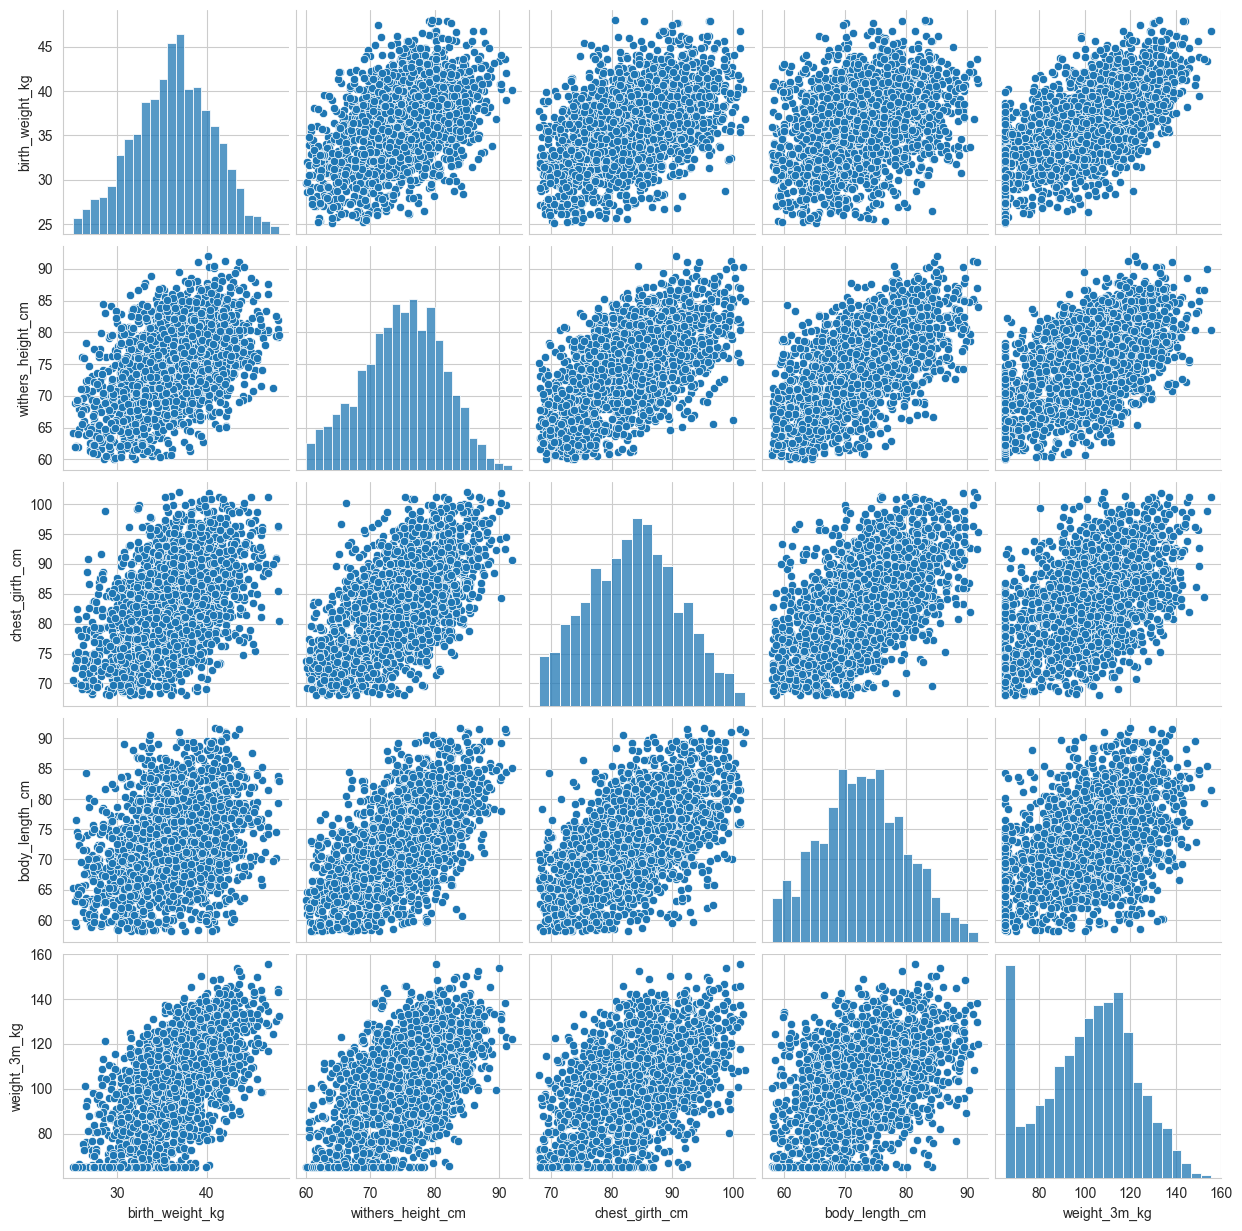

In [29]:
sns.pairplot(df[[
    "birth_weight_kg",
    "withers_height_cm",
    "chest_girth_cm",
    "body_length_cm",
    "weight_3m_kg"
]])
plt.show()

# Modeling

## 🤖 Model Design Strategy

**TR:** Bu çalışmada veri erişimine bağlı olarak iki ayrı model yaklaşımı uygulanmıştır. İlk model (Model A), 3 aylık canlı ağırlık verisi bulunmadığında erken tahmin yapmak amacıyla geliştirilmiştir. İkinci model (Model B) ise 3 aylık ağırlık bilgisi mevcut olduğunda daha doğru tahminler üretmek için kullanılmıştır.

**EN:** In this study, a two-model approach was implemented based on data availability. The first model (Model A) is designed for early prediction when 3-month weight data is not available. The second model (Model B) leverages the 3-month weight to produce more accurate predictions.

---


In [30]:
# Target
y = df["weight_12m_kg"]

In [31]:
# Model A (3m yok) - animal_id ve gereksiz kiloları atıyoruz
X_A = df.drop(columns=["animal_id", "weight_12m_kg", "weight_6m_kg", "weight_3m_kg"])

In [32]:
# Model B (3m var) - animal_id ve gereksiz kiloları atıyoruz
X_B = df.drop(columns=["animal_id", "weight_12m_kg", "weight_6m_kg"])

In [33]:
# Train | Test Split

from sklearn.model_selection import train_test_split

# Model A
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y, test_size=0.2, random_state=42)

# Model B
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y, test_size=0.2, random_state=42)

## 🔀 Train-Test Split

**TR:** Veri seti %80 eğitim ve %20 test olacak şekilde bölünmüştür. Bu ayrım, modelin genelleme performansını değerlendirmek için kullanılmıştır.

**EN:** The dataset was split into 80% training and 20% testing sets to evaluate the generalization performance of the models.


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- 1. DİNAMİK KOLON SEÇİMİ ---
# Kategorik ve sayısal kolonları otomatik olarak yakalayalım (isimleri elle yazmaktan kurtarır)
cat_cols_A = X_train_A.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_A = X_train_A.select_dtypes(exclude=['object', 'category']).columns.tolist()

cat_cols_B = X_train_B.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_B = X_train_B.select_dtypes(exclude=['object', 'category']).columns.tolist()

# --- 2. DÖNÜŞTÜRÜCÜLER (PREPROCESSORS) ---
preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_A),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_A)
    ])

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_B),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_B)
    ])

# --- 3. PIPELINE VE MODEL KURULUMU ---
# Şimdilik sağlam ve stabil olan Random Forest ile başlıyoruz. (İleride XGBoost da deneriz)
model_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

# --- 4. MODELLERİN EĞİTİLMESİ (TRAINING) ---
print("Model A (3. Ay Kilosu YOK) eğitiliyor...")
model_A.fit(X_train_A, y_train_A)

print("Model B (3. Ay Kilosu VAR) eğitiliyor...")
model_B.fit(X_train_B, y_train_B)
print("Eğitim tamamlandı! 🚀")

Model A (3. Ay Kilosu YOK) eğitiliyor...


Model B (3. Ay Kilosu VAR) eğitiliyor...


Eğitim tamamlandı! 🚀


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib
import os

# --- 1. YARIŞACAK MODELLER SÖZLÜĞÜ ---
modeller = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

# --- 2. ŞAMPİYONU BULAN FONKSİYON ---
def en_iyi_modeli_bul(X_train, y_train, X_test, y_test, preprocessor, model_adi):
    en_iyi_isim = ""
    en_iyi_model = None
    en_dusuk_mae = float('inf') # Sonsuzdan başlatıyoruz ki gelen her küçük değer bunu ezsin
    
    print(f"\n{'='*40}")
    print(f" 🏆 {model_adi} İÇİN TURNUVA BAŞLADI 🏆")
    print(f"{'='*40}")
    
    for isim, algoritma in modeller.items():
        # Her model için boru hattını (pipeline) sıfırdan kur
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", algoritma)
        ])
        
        # Eğit
        pipeline.fit(X_train, y_train)
        
        # Test verisiyle tahmin yap ve Hata (MAE/RMSE) hesapla
        preds = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        
        print(f"✔️ {isim:<18} -> MAE: {mae:.2f} kg | RMSE: {rmse:.2f} kg")
        
        # Eğer bu modelin hatası şu ana kadarki en düşük hataysa, tahta o geçsin
        if mae < en_dusuk_mae:
            en_dusuk_mae = mae
            en_iyi_isim = isim
            en_iyi_model = pipeline
            
    print("-" * 40)
    print(f"🚀 KAZANAN MODEL: {en_iyi_isim} (Hata: {en_dusuk_mae:.2f} kg)\n")
    return en_iyi_model

# --- 3. TURNUVAYI BAŞLAT VE EN İYİLERİ AL ---
# Model A (Erken Tahmin - 3 Ay Yok) için en iyiyi buluyoruz
best_model_A = en_iyi_modeli_bul(X_train_A, y_train_A, X_test_A, y_test_A, preprocessor_A, "MODEL A (3 AY KİLOSU YOK)")

# Model B (Güncellenmiş Tahmin - 3 Ay Var) için en iyiyi buluyoruz
best_model_B = en_iyi_modeli_bul(X_train_B, y_train_B, X_test_B, y_test_B, preprocessor_B, "MODEL B (3 AY KİLOSU VAR)")

# --- 4. SADECE KAZANAN MODELLERİ (ŞAMPİYONLARI) KAYDET ---
os.makedirs("models", exist_ok=True)
joblib.dump(best_model_A, 'models/model_A_early_pred.pkl')
joblib.dump(best_model_B, 'models/model_B_updated_pred.pkl')

print("✅ Şampiyon modeller 'models' klasörüne başarıyla kaydedildi! Streamlit uygulamasını yenileyebilirsin.")


 🏆 MODEL A (3 AY KİLOSU YOK) İÇİN TURNUVA BAŞLADI 🏆
✔️ Linear Regression  -> MAE: 17.16 kg | RMSE: 21.38 kg


✔️ Random Forest      -> MAE: 19.47 kg | RMSE: 24.93 kg


✔️ Gradient Boosting  -> MAE: 17.32 kg | RMSE: 21.84 kg


✔️ XGBoost            -> MAE: 18.87 kg | RMSE: 24.50 kg
----------------------------------------
🚀 KAZANAN MODEL: Linear Regression (Hata: 17.16 kg)


 🏆 MODEL B (3 AY KİLOSU VAR) İÇİN TURNUVA BAŞLADI 🏆
✔️ Linear Regression  -> MAE: 14.76 kg | RMSE: 18.64 kg


✔️ Random Forest      -> MAE: 16.67 kg | RMSE: 21.31 kg


✔️ Gradient Boosting  -> MAE: 15.67 kg | RMSE: 19.65 kg
✔️ XGBoost            -> MAE: 17.64 kg | RMSE: 22.19 kg
----------------------------------------
🚀 KAZANAN MODEL: Linear Regression (Hata: 14.76 kg)



✅ Şampiyon modeller 'models' klasörüne başarıyla kaydedildi! Streamlit uygulamasını yenileyebilirsin.


In [41]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import joblib

# --- 1. XGBOOST İÇİN DENENECEK AYARLAR (PARAMETRE UZAYI) ---
# Model bu listedeki değerleri karıştırıp en iyi kombinasyonu arayacak
param_grid = {
    'regressor__n_estimators': [100, 300, 500, 800],           # Ağaç sayısı
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],        # Öğrenme hızı (Küçük adımlar genelde iyidir)
    'regressor__max_depth': [3, 4, 5, 7],                      # Ağaçların derinliği (Fazlası ezber yaptırır)
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],              # Verinin yüzde kaçını kullanarak öğrensin
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0]        # Kolonların yüzde kaçını kullansın
}

# --- 2. EN İYİ XGBOOST'U BULAN FONKSİYON ---
def xgboost_canavari_yarat(X_train, y_train, preprocessor, model_adi):
    print(f"\n{'='*45}")
    print(f"🔥 {model_adi} İÇİN XGBOOST EĞİTİLİYOR 🔥")
    print(f"{'='*45}")
    
    # Boş XGBoost modelimizi boru hattına ekliyoruz
    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(random_state=42, objective='reg:squarederror'))
    ])
    
    # RandomizedSearchCV ile kombinasyonları deneme
    # n_iter=30 demek, yukarıdaki binlerce kombinasyon içinden rastgele 30 tanesini dene demek. 
    # cv=3 (Cross-validation) veriyi 3'e bölüp test ederek ezberi önler.
    random_search = RandomizedSearchCV(
        xgb_pipeline, 
        param_distributions=param_grid, 
        n_iter=30, 
        cv=3, 
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1, # İşlemcinin tüm çekirdeklerini kullanır (Hızlandırır)
        verbose=1  # Ekrana süreçle ilgili bilgi basar
    )
    
    random_search.fit(X_train, y_train)
    
    # En iyi modelin hangi ayarlarla bulunduğunu yazdır
    print(f"\n✅ En İyi Ayarlar Bulundu:")
    for ayar, deger in random_search.best_params_.items():
        print(f"   👉 {ayar.split('__')[1]}: {deger}")
        
    return random_search.best_estimator_

# --- 3. EĞİTİMİ BAŞLAT ---
# İşlemcinin gücüne göre bu kısım birkaç dakika sürebilir, arkana yaslan bekle!
tuned_xgb_A = xgboost_canavari_yarat(X_train_A, y_train_A, preprocessor_A, "MODEL A (3 AY YOK)")
tuned_xgb_B = xgboost_canavari_yarat(X_train_B, y_train_B, preprocessor_B, "MODEL B (3 AY VAR)")

# --- 4. SONUÇLARI TEST ET VE ESKİ ŞAMPİYONLA KIYASLA ---
preds_A = tuned_xgb_A.predict(X_test_A)
mae_A = mean_absolute_error(y_test_A, preds_A)
rmse_A = np.sqrt(mean_squared_error(y_test_A, preds_A))

preds_B = tuned_xgb_B.predict(X_test_B)
mae_B = mean_absolute_error(y_test_B, preds_B)
rmse_B = np.sqrt(mean_squared_error(y_test_B, preds_B))

print("\n" + "*" * 45)
print("🚀 TUNING SONRASI YENİ XGBOOST PERFORMANSI 🚀")
print("*" * 45)
print(f"Model A (Eski Şampiyon LR: 17.16 kg)")
print(f"👉 YENİ XGBoost MAE: {mae_A:.2f} kg | RMSE: {rmse_A:.2f} kg\n")

print(f"Model B (Eski Şampiyon LR: 14.76 kg)")
print(f"👉 YENİ XGBoost MAE: {mae_B:.2f} kg | RMSE: {rmse_B:.2f} kg")
print("*" * 45)


🔥 MODEL A (3 AY YOK) İÇİN XGBOOST EĞİTİLİYOR 🔥
Fitting 3 folds for each of 30 candidates, totalling 90 fits



✅ En İyi Ayarlar Bulundu:
   👉 subsample: 0.9
   👉 n_estimators: 300
   👉 max_depth: 3
   👉 learning_rate: 0.05
   👉 colsample_bytree: 0.7

🔥 MODEL B (3 AY VAR) İÇİN XGBOOST EĞİTİLİYOR 🔥
Fitting 3 folds for each of 30 candidates, totalling 90 fits



✅ En İyi Ayarlar Bulundu:
   👉 subsample: 0.8
   👉 n_estimators: 800
   👉 max_depth: 3
   👉 learning_rate: 0.01
   👉 colsample_bytree: 0.9

*********************************************
🚀 TUNING SONRASI YENİ XGBOOST PERFORMANSI 🚀
*********************************************
Model A (Eski Şampiyon LR: 17.16 kg)
👉 YENİ XGBoost MAE: 17.43 kg | RMSE: 22.17 kg

Model B (Eski Şampiyon LR: 14.76 kg)
👉 YENİ XGBoost MAE: 15.38 kg | RMSE: 19.31 kg
*********************************************


In [42]:
# Farklı farklı modeller eğitilip denenmiştir ama en iyi sonuçlar Linear Regression ile alınmıştır.

# Karar Destek Motoru

In [37]:
def karar_destek_motoru(tahmin_edilen_kilo, irk, cinsiyet):
    """
    Tahmin edilen kiloyu ırk ve cinsiyet hedeflerine göre kıyaslar 
    ve çiftçiye aksiyon önerisi sunar.
    """
    
    # 1. 12 Aylık Hedef Kilolar (Kanka burayı kendi verindeki ırklara göre revize edebilirsin)
    # Örnek: Erkek Holstein 12 ayda ortalama 400kg, Dişisi 350kg hedeflenir.
    hedef_kilolar = {
        "Holstein": {"Male": 400, "Female": 350},
        "Angus": {"Male": 450, "Female": 400},
        "Simmental": {"Male": 430, "Female": 380}
    }
    
    # 2. İlgili ırk sözlükte var mı kontrolü (Yoksa genel bir ortalama alıyoruz)
    if irk in hedef_kilolar and cinsiyet in hedef_kilolar[irk]:
        hedef_kilo = hedef_kilolar[irk][cinsiyet]
    else:
        hedef_kilo = 400 # Bilinmeyen ırk/cinsiyet için default değer
        
    # 3. Performans Hesaplama (% kaçına ulaştı?)
    performans_orani = (tahmin_edilen_kilo / hedef_kilo) * 100
    
    # 4. Kural Tabanlı Yorumlama (Rule-Based Logic)
    if performans_orani < 90:
        durum = "🔴 DÜŞÜK PERFORMANS RİSKİ"
        oneri = f"Beklenen ağırlık ({tahmin_edilen_kilo:.1f} kg), hedefin ({hedef_kilo} kg) altında. Rasyondaki enerji ve protein yoğunluğunu artırmanız veya erken kesim senaryolarını değerlendirmeniz önerilir."
        
    elif 90 <= performans_orani <= 110:
        durum = "🟢 OPTİMAL GELİŞİM"
        oneri = f"Beklenen ağırlık ({tahmin_edilen_kilo:.1f} kg), hedef ({hedef_kilo} kg) ile uyumlu. Mevcut besleme ve bakım stratejisine devam edebilirsiniz."
        
    else:
        durum = "🌟 YÜKSEK PERFORMANS"
        oneri = f"Beklenen ağırlık ({tahmin_edilen_kilo:.1f} kg), hedefin ({hedef_kilo} kg) oldukça üzerinde. Hayvan besiye harika yanıt veriyor, rasyon maliyeti optimize edilerek karlılık maksimize edilebilir."
        
    return durum, oneri

# --- KÜÇÜK BİR TEST YAPALIM ---
# Diyelim ki Model A, bir Erkek Holstein için 355 kg tahmin yaptı.
ornek_durum, ornek_oneri = karar_destek_motoru(355, "Holstein", "Male")

print("--- ÖRNEK KARAR DESTEK ÇIKTISI ---")
print(f"Durum: {ornek_durum}")
print(f"Öneri: {ornek_oneri}")

--- ÖRNEK KARAR DESTEK ÇIKTISI ---
Durum: 🔴 DÜŞÜK PERFORMANS RİSKİ
Öneri: Beklenen ağırlık (355.0 kg), hedefin (400 kg) altında. Rasyondaki enerji ve protein yoğunluğunu artırmanız veya erken kesim senaryolarını değerlendirmeniz önerilir.


# Export

In [38]:
import joblib
import os

# Kaydedilecek klasörü belirleyelim (Notebook'un olduğu yerde 'models' diye klasör açar)
os.makedirs("models", exist_ok=True)

# Model A'yı Kaydet (İçinde Preprocessor + Random Forest var)
joblib.dump(model_A, 'models/model_A_early_pred.pkl')
print("✅ Model A başarıyla kaydedildi: 'models/model_A_early_pred.pkl'")

# Model B'yi Kaydet
joblib.dump(model_B, 'models/model_B_updated_pred.pkl')
print("✅ Model B başarıyla kaydedildi: 'models/model_B_updated_pred.pkl'")

✅ Model A başarıyla kaydedildi: 'models/model_A_early_pred.pkl'
✅ Model B başarıyla kaydedildi: 'models/model_B_updated_pred.pkl'


In [39]:
df.head()

,animal_id,breed,sex,birth_weight_kg,withers_height_cm,chest_girth_cm,body_length_cm,colostrum_liters_first_week,early_health_score,ration_type,daily_dry_matter_intake_kg,disease_history_first_3m,weight_3m_kg,weight_6m_kg,weight_12m_kg
0,ANM-00001,Hereford,Female,31.1,74.4,77.1,61.6,24.8,5,high_energy,5.22,0,105.3,205.1,344.3
1,ANM-00002,Jersey,Male,40.8,70.3,78.6,59.7,8.6,4,standard,4.67,0,88.0,177.4,282.6
2,ANM-00003,Limuzin,Female,41.3,77.7,87.9,76.0,25.0,3,high_protein,5.52,1,109.9,188.2,296.6
3,ANM-00004,Angus,Female,33.1,75.8,92.0,85.7,25.0,5,standard,5.44,0,117.4,213.3,336.9
4,ANM-00005,Holstein,Male,39.1,79.1,87.0,73.8,22.2,4,high_energy,6.67,0,129.4,259.2,465.5
